# Correct Misannotation of MgkPro as HSCs.

## Prepare Notebook.

### Import Libraries.

In [12]:
import logging
import sys

from hydra import compose, initialize
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
from scipy.stats import gaussian_kde
import seaborn as sns


sys.path.insert(0, "../../shared_utils")
from experiment_utils import get_forward_model


### Load Data.

In [2]:
adata_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/LPHO014/Loop2_Loop2p5_Loop3_Loop4_Loop4p5/Loop2_logicle_500k.h5ad"
adata = sc.read_h5ad(adata_path)
adata

AnnData object with n_obs × n_vars = 499995 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps'
    layers: 'positives', 'raw'

## Annotate Data.

### Load Configurations.

In [7]:
with initialize(
    config_path="../../inverse/loss_guidance/config",
    version_base=None
):
    config = compose(
        config_name="run_inverse",
        overrides=[
            "annotation=bloodplus",
            "paths=bloodplus"
        ]
    )


### Load Model.

In [13]:
logger = logging.getLogger(__name__)

forward_model, (
    flow_matching,
    target_prediction_model
) = get_forward_model(config, logger=logger)


[2026-06-16 16:53:35] - __main__: Loading Perturbation Response Prediction Model From /lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/conditional_model/flow_matching/2026-04-02_14-16-39/eager-feather-1_FlowMatching.pkl...
[2026-06-16 16:56:28] - __main__: Model loaded!
NeuralVelocityField(
  (vf_modules): ModuleDict(
    (x_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=26, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=512, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        (2): Sequential(
          (0): Linear(in_features=512, out_features=1024, bias=True)
          (1): Identity()
        )
      )
    )
    (time_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): ELU(alpha=1.0)
 

In [17]:
train_adata_g = target_prediction_model.train_data.adata
scatter_params = train_adata_g.uns["X_scatter_params"]
channel_params = train_adata_g.uns["X_channel_params"]
scatter_params.keys(), channel_params.keys()

(dict_keys(['mean', 'std']), dict_keys(['mean', 'std']))

In [22]:
X_channel = adata.X

X_channel = (X_channel - channel_params["mean"])/channel_params["std"]

X_scatter = []
for col in config.annotation.scatter_columns:
    col_vals = adata.obs[col].astype(float).values
    X_scatter.append(col_vals)
X_scatter = np.stack(X_scatter, axis=1)
X_scatter = (X_scatter - scatter_params["mean"])/scatter_params["std"]


X = np.concatenate(
    (
        X_channel, X_scatter
    ), axis=1
)
print(f"{X_channel.shape=} {X_scatter.shape=}")


X_channel.shape=(499995, 20) X_scatter.shape=(499995, 6)


In [33]:
from torch.utils.data import TensorDataset, DataLoader
import torch
from tqdm.auto import tqdm

dataloader = DataLoader(
    torch.utils.data.TensorDataset(torch.from_numpy(X)), 
    batch_size=4026,
    shuffle=False
)

ct_predictions = []
with torch.no_grad():
    for batch in tqdm(dataloader):
        X_batch = batch[0].to(target_prediction_model.device).to(torch.float32)
        y_pred = target_prediction_model.predict(X_batch)["cell_type"].argmax(1)
        ct_predictions.append(y_pred.cpu().detach().numpy())
ct_predictions = np.concatenate(ct_predictions)

  0%|          | 0/125 [00:00<?, ?it/s]

In [31]:
from sklearn.preprocessing import LabelEncoder

# Prepare label encoder
ct_le = LabelEncoder()
ct_values = train_adata_g.obs["cell_type"].values
ct_le.fit(ct_values)
classes = np.array(ct_le.classes_.tolist())

In [35]:
ct_predictions_str = classes[ct_predictions]
ct_predictions_str.shape

(499995,)

In [36]:
adata.obs["cell_type"] = ct_predictions_str

In [57]:
adata.obs.experiment_number.unique()

['244', '245', '243', '240', '247', '246', '242', '241', '239']
Categories (9, object): ['239', '240', '241', '242', ..., '244', '245', '246', '247']

In [65]:
settings_experiments_map = {
    239:"late_mgkPro_low_u",
    240:"late_mgkPro_high_u0",
    248:"late_mgkPro_high_u1",
    241: "EryPro_low_u",
    242: "EryPro_high_u0",
    249: "EryPro_high_u1",
    243: "HSC_low_u",
    223: "HSC_high_u0",
    244: "HSC_high_u1",
    250: "preProB_low_u",
    245: "preProB_high_u0",
    246: "preProB_low_u",
    251: "preProB_high_u2",
}
adata_enrichment = adata[
    adata.obs.experiment_number.map(lambda e: int(e) in settings_experiments_map)
].copy()
adata_enrichment.obs["enrichment_type"] = adata_enrichment.obs.experiment_number.map(lambda e: settings_experiments_map[int(e)])


/tmp/ipykernel_2550474/541161448.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('enrichment_type')[cell_type_col]
/tmp/ipykernel_2550474/541161448.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for etype, grp in props.groupby('enrichment_type'):


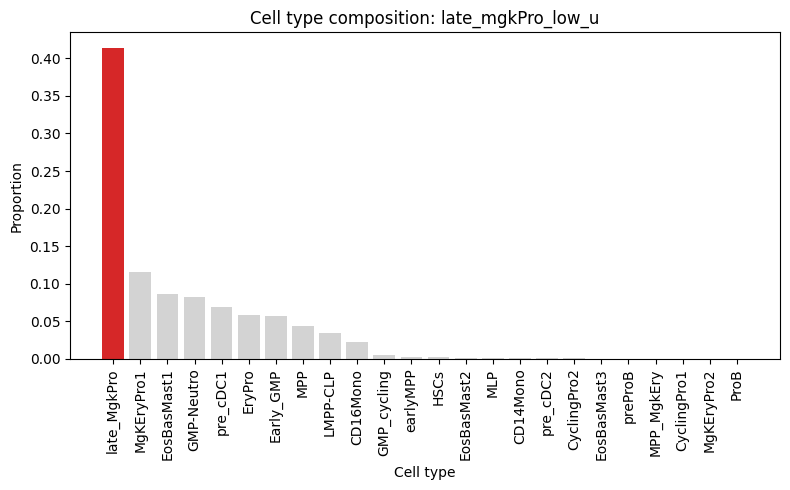

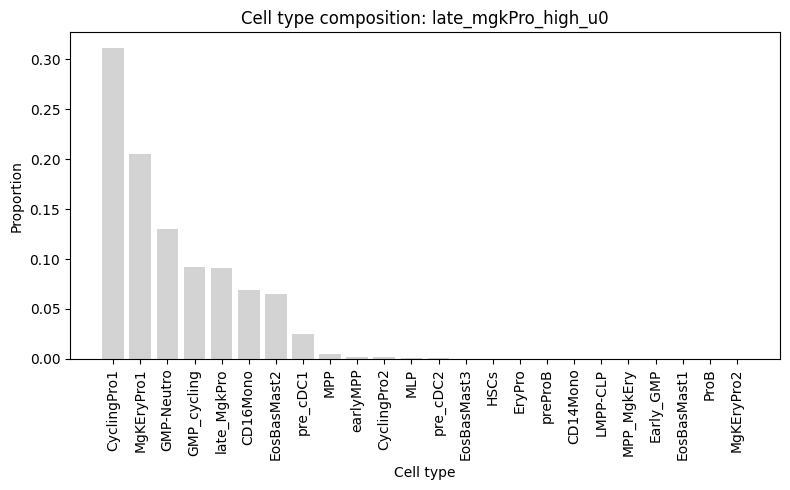

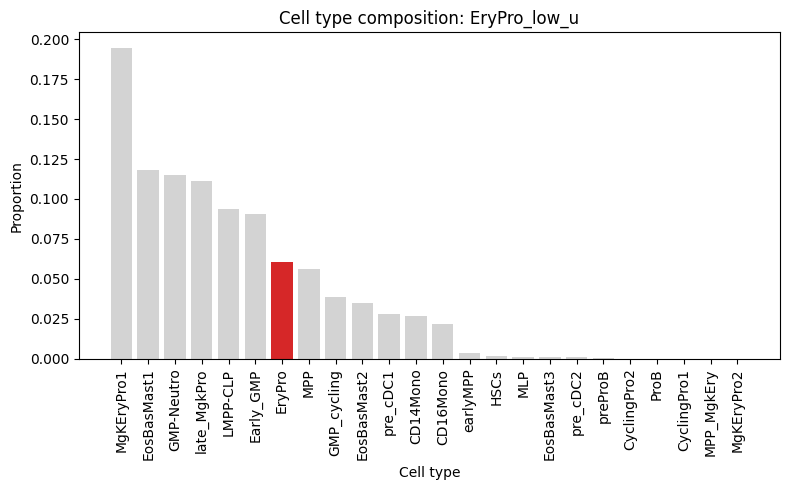

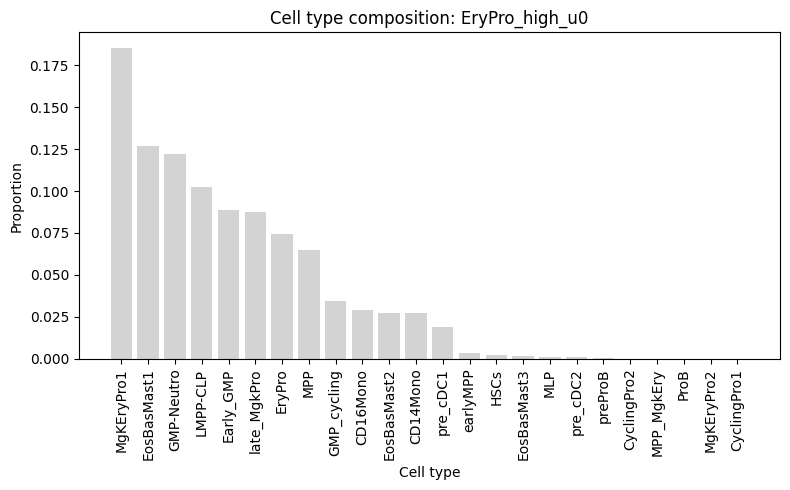

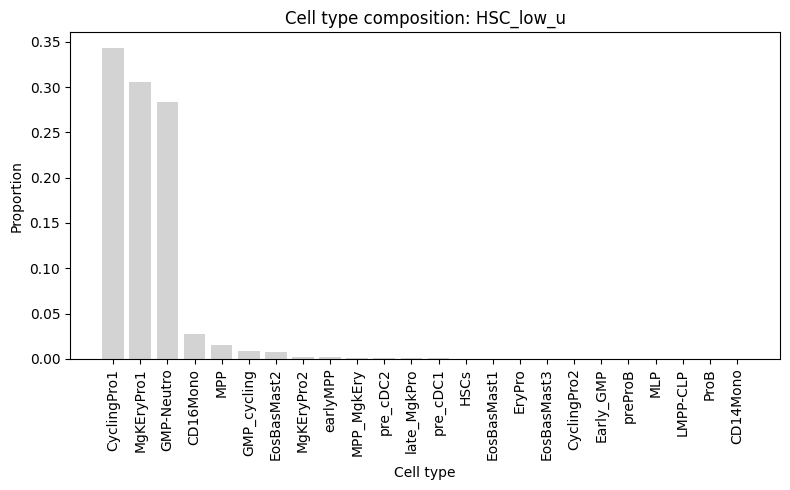

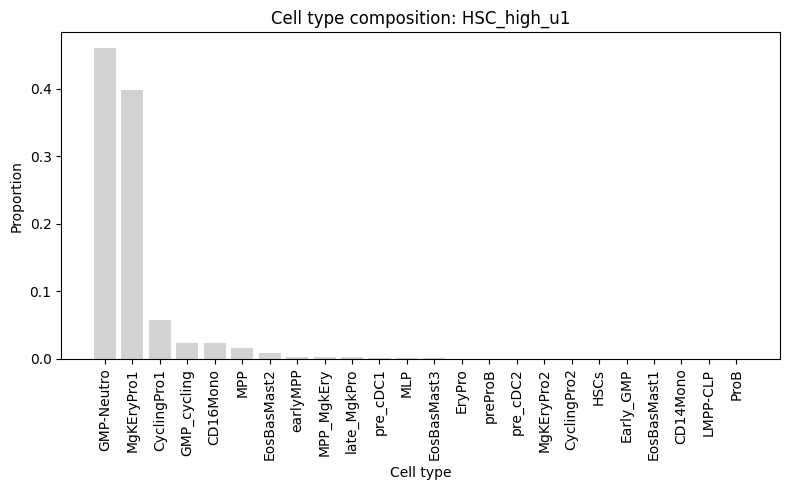

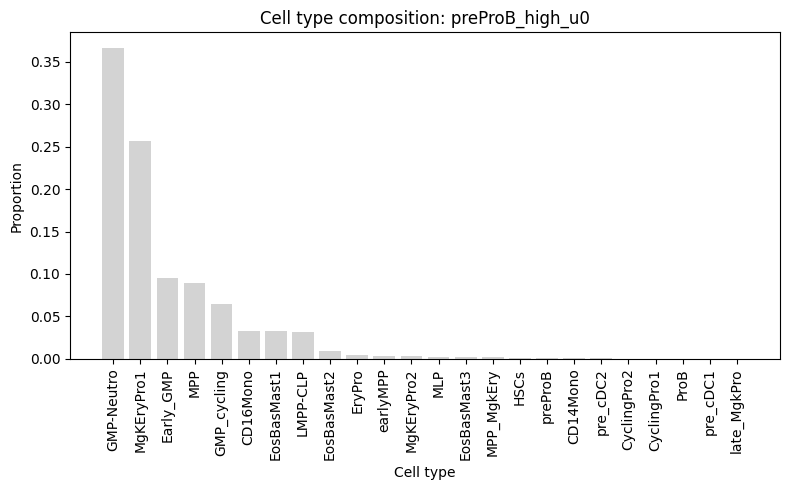

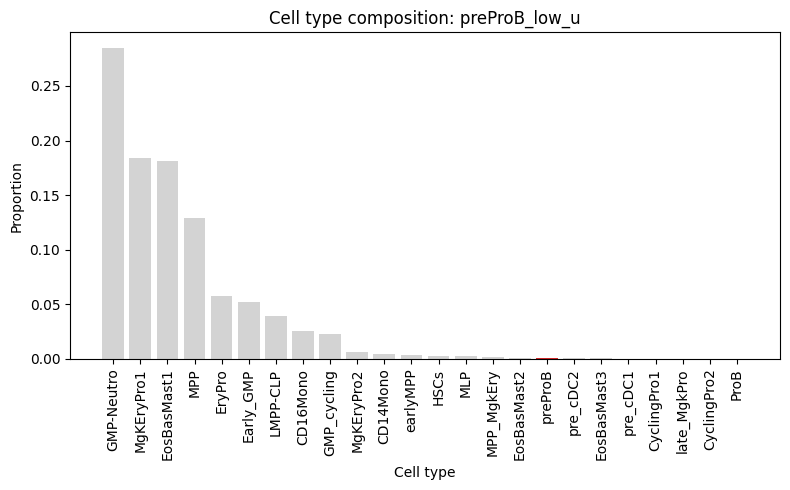

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

# --- ADAPT THESE ---
cell_type_col = 'cell_type'          # column with cell type labels

# Mapping from enrichment_type to target cell type(s) – use the exact string(s) from your data
target_map = {
    'late_mgkPro_low_u':  ['late_MgkPro'],
    'late_mgkPro_high_u': ['late_MgkPro'],
    'EryPro_low_u':       ['EryPro'],
    'EryPro_high_u':      ['EryPro'],
    'HSC_low_u':          ['HSC'],
    'HSC_high_u':         ['HSC'],
    'preProB_low_u':      ['preProB'],
    'preProB_high_u':     ['preProB'],
}

# Compute proportions
props = (
    adata_enrichment.obs
    .groupby('enrichment_type')[cell_type_col]
    .value_counts(normalize=True)
    .rename('proportion')
    .reset_index()
)

# Plot one bar chart per enrichment type
for etype, grp in props.groupby('enrichment_type'):
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Determine target cell types for this enrichment
    targets = target_map.get(etype, [])
    
    # Bar colors: red if the cell type is a target, else light gray
    colors = ['#d62728' if ct in targets else '#d3d3d3' for ct in grp[cell_type_col]]
    
    ax.bar(grp[cell_type_col], grp['proportion'], color=colors)
    
    ax.set_title(f'Cell type composition: {etype}')
    ax.set_xlabel('Cell type')
    ax.set_ylabel('Proportion')
    ax.tick_params(axis='x', rotation=90)
    plt.tight_layout()
    plt.show()